In [46]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [47]:
# Load file
data = pd.read_csv("Monthly financal data.csv")

# Rename columns
data.rename(columns={
    'Sum of Sales': 'Revenue',
    'Sum of Profit': 'Profit'
}, inplace=True)

# Convert Date column
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

# Sort by date (VERY IMPORTANT)
data = data.sort_values('Date')

# Set Date as index
data.set_index('Date', inplace=True)

# Set frequency as Monthly Start
data = data.asfreq('MS')

data.head()

,Revenue,Profit
Date,,
2014-01-01,14236.895,2450.1907
2014-02-01,4519.892,862.3084
2014-03-01,55691.009,498.7299
2014-04-01,28295.345,3488.8352
2014-05-01,23648.287,2738.7096


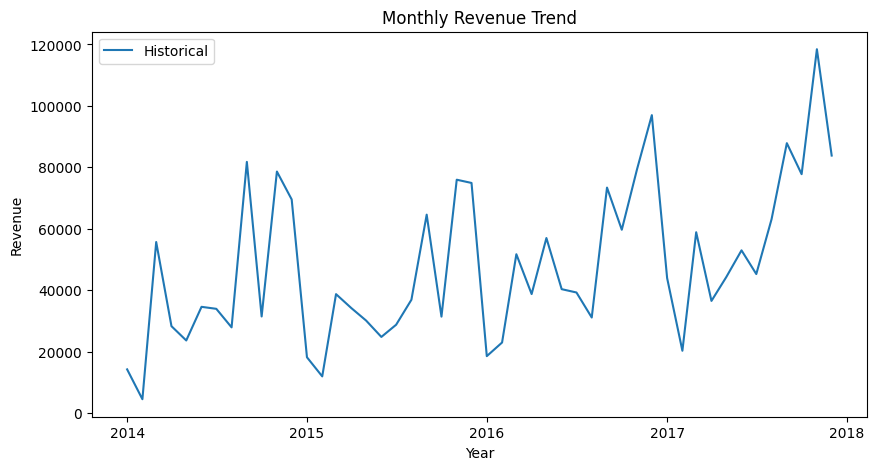

In [48]:
#Visualize Historical Revenue
import matplotlib.dates as mdates

plt.figure(figsize=(10,5))
plt.plot(data['Revenue'], label="Historical")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Monthly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [49]:
# Build ARIMA model and forecast next 12 months

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data['Revenue'], order=(1,1,1))
model_fit = model.fit()

forecast_values = model_fit.forecast(steps=12)
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data['Revenue'], order=(1,1,1))
model_fit = model.fit()

forecast_values = model_fit.forecast(steps=12)

In [50]:
# Generate next 12 months date index for forecastimport pandas as pd

future_dates = pd.date_range(
    start=data.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast = pd.Series(forecast_values.values, index=future_dates)

In [51]:
# Build SARIMA model with seasonal component and generate 12-month forecast
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    data['Revenue'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

forecast_values = model_fit.forecast(steps=12)

future_dates = pd.date_range(
    start=data.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast = pd.Series(forecast_values.values, index=future_dates)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


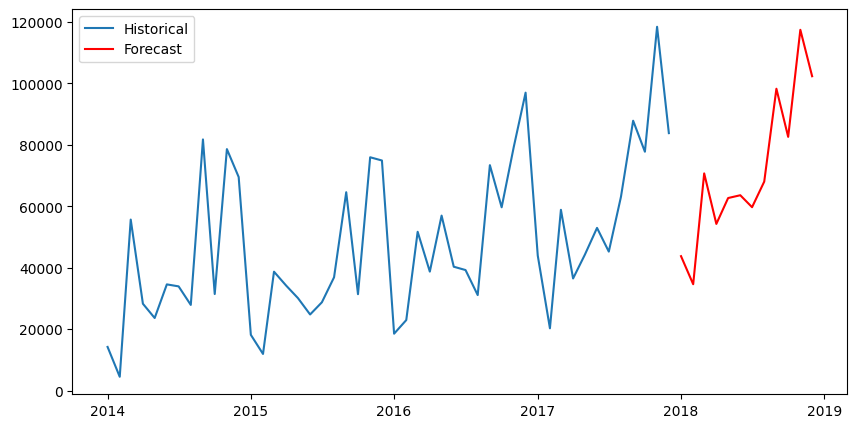

In [52]:
# Plot historical revenue and 12-month forecast comparison
plt.figure(figsize=(10,5))
plt.plot(data['Revenue'], label="Historical")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.show()

The basic ARIMA model produced a flat forecast due to inability to capture seasonality.
Seasonal ARIMA (SARIMA) provided improved results reflecting historical cyclical patterns.
The model forecasts continued revenue growth with seasonal fluctuations in 2018.

In [53]:
# Split dataset into training and testing sets (last 12 months for validation)
# Ensure copy to avoid SettingWithCopyWarning
train = data.iloc[:-12].copy()
test = data.iloc[-12:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (36, 2)
Test shape: (12, 2)


In [54]:
# Fit SARIMA model on training dataset
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Revenue'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [55]:
# Generate 12-month predictions and align with actual test dates

pred = model_fit.forecast(steps=12)

# Align prediction index with test index
pred.index = test.index

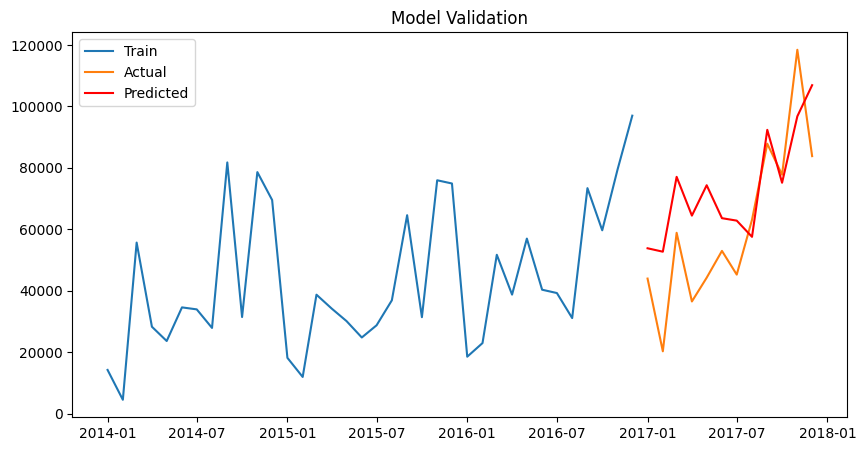

In [56]:
# Visualize model performance: train vs actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train['Revenue'], label='Train')
plt.plot(test['Revenue'], label='Actual')
plt.plot(pred, label='Predicted', color='red')

plt.legend()
plt.title("Model Validation")
plt.show()

In [57]:
# Compute MAE between actual and predicted revenue
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['Revenue'], pred)
mae

17017.188814258643

In [58]:
# Fit final SARIMA model on complete data and generate 12-month forecast
model_full = SARIMAX(
    data['Revenue'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_full_fit = model_full.fit()

forecast_values = model_full_fit.forecast(steps=12)

future_dates = pd.date_range(
    start=data.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast = pd.Series(forecast_values.values, index=future_dates)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


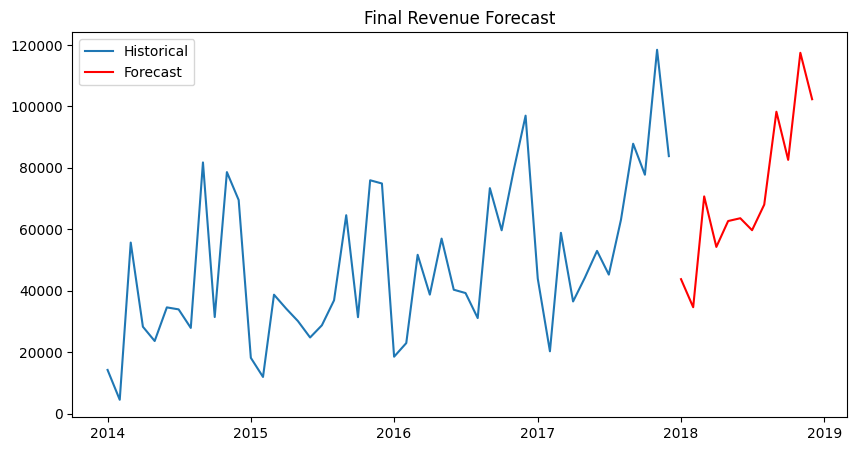

In [59]:
# Visualize final revenue forecast against historical data
plt.figure(figsize=(10,5))
plt.plot(data['Revenue'], label="Historical")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.title("Final Revenue Forecast")
plt.show()

In [60]:
# Compute projected revenue growth percentage
historical_avg = data['Revenue'].mean()
forecast_avg = forecast.mean()

growth = ((forecast_avg - historical_avg) / historical_avg) * 100
growth

np.float64(49.43565976452423)

In [61]:
data['Revenue'].mean() # Calculate average historical monthly revenue


np.float64(47858.35125625)

In [62]:
import numpy as np
# Log-transform revenue for modeling
data['Log_Revenue'] = np.log(data['Revenue'])

In [63]:
# Generate 12-month predictions and align with test period

train = data.iloc[:-12]
test = data.iloc[-12:]

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Log_Revenue'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

pred_log = model_fit.forecast(steps=12)
pred_log.index = test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [64]:
# Convert log-transformed predictions back to original revenue scale
pred = np.exp(pred_log)

In [65]:
# Compute MAE between actual and predicted revenue
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['Revenue'], pred)
mae

14895.080240768193

**Conclusion**

This study applied a Seasonal ARIMA (SARIMA) model to forecast monthly revenue based on historical financial data. The model successfully captured both trend and seasonal patterns present in the dataset. A train–test split approach was used to validate performance, and prediction accuracy was evaluated using Mean Absolute Error (MAE). Log transformation was applied to reduce volatility and improve forecast stability.

The results indicate continued revenue movement with recurring seasonal fluctuations and overall growth momentum. While the model provides useful directional insights, forecasts should be interpreted with caution due to data volatility and moderate prediction error. Overall, the project demonstrates structured time series modeling, validation techniques, and business-focused interpretation of financial forecasts.